In [14]:
!pip install torch

In [15]:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [16]:
df = pd.read_csv('pickeringWind.csv', parse_dates=['time'])
df.head()


,time,temperature_2m,wind_speed_10m,wind_speed_100m,wind_direction_10m,cloud_cover_mid,cloud_cover_high,cloud_cover_low,cloud_cover,surface_pressure,...,wind_gusts_10m,vapour_pressure_deficit,pressure_msl,snow_depth,rain,snowfall,apparent_temperature,dew_point_2m,relative_humidity_2m,precipitation
0,2015-01-01 00:00:00,temperature_2m (°C),22.4,36.4,242.0,56.0,0.0,98.0,99.0,988.3,...,44.6,0.19,1016.4,0.01,0.0,0.0,-13.8,-16.2,48.0,0.0
1,2015-01-01 01:00:00,temperature_2m (°C),22.2,36.4,241.0,23.0,0.0,24.0,39.0,987.7,...,44.3,0.18,1015.8,0.01,0.0,0.0,-14.1,-15.9,50.0,0.0
2,2015-01-01 02:00:00,temperature_2m (°C),22.0,36.4,238.0,41.0,0.0,19.0,43.0,986.9,...,43.2,0.17,1015.0,0.01,0.0,0.0,-14.4,-15.8,52.0,0.0
3,2015-01-01 03:00:00,temperature_2m (°C),21.5,35.7,235.0,39.0,0.0,58.0,63.0,986.3,...,45.4,0.17,1014.4,0.01,0.0,0.0,-14.3,-16.0,51.0,0.0
4,2015-01-01 04:00:00,temperature_2m (°C),22.1,36.5,236.0,7.0,0.0,33.0,34.0,986.1,...,43.6,0.16,1014.2,0.01,0.0,0.0,-14.2,-15.2,54.0,0.0


In [34]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 1. Load and inspect the data
df = pd.read_csv('pickeringWind.csv', parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)
print("Raw data head:")
print(df.head(10))

# Define the relevant columns.
features = ['wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'pressure_msl', 'temperature_2m']
target = 'wind_speed_10m'  # We will predict wind_speed_10m

# Select only the needed columns.
data = df[features].copy()

# Clean the data:
# Remove any non-numeric characters (like extra header text or units)
data = data.replace(r'[^\d.-]', '', regex=True)

# Convert columns to numeric values.
data[features] = data[features].apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN values.
data = data.dropna().reset_index(drop=True)
print("Cleaned data shape:", data.shape)
print("Cleaned data head:")
print(data.head())


Raw data head:
                 time       temperature_2m  wind_speed_10m  wind_speed_100m  \
0 2015-01-01 00:00:00  temperature_2m (°C)            22.4             36.4   
1 2015-01-01 01:00:00  temperature_2m (°C)            22.2             36.4   
2 2015-01-01 02:00:00  temperature_2m (°C)            22.0             36.4   
3 2015-01-01 03:00:00  temperature_2m (°C)            21.5             35.7   
4 2015-01-01 04:00:00  temperature_2m (°C)            22.1             36.5   
5 2015-01-01 05:00:00  temperature_2m (°C)            21.2             35.6   
6 2015-01-01 06:00:00  temperature_2m (°C)            20.2             34.2   
7 2015-01-01 07:00:00  temperature_2m (°C)            21.4             35.9   
8 2015-01-01 08:00:00  temperature_2m (°C)            23.9             39.5   
9 2015-01-01 09:00:00  temperature_2m (°C)            23.2             37.8   

   wind_direction_10m  cloud_cover_mid  cloud_cover_high  cloud_cover_low  \
0               242.0             56.0

In [35]:
sequence_length = 24

def create_sequences(X, y, seq_length):
    seq_X, seq_y = [], []
    for i in range(len(X) - seq_length):
        seq_X.append(X[i:i+seq_length])
        seq_y.append(y[i+seq_length])
    return np.array(seq_X), np.array(seq_y)

X_seq, y_seq = create_sequences(data_features, data_target, sequence_length)
print("Input shape:", X_seq.shape, "Target shape:", y_seq.shape)

Input shape: (0,) Target shape: (0,)


In [36]:
train_size = int(len(X_seq) * 0.75)
X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_test, y_test = X_seq[train_size:], y_seq[train_size:]

# Define PyTorch Dataset for the sequences.
class WindDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = WindDataset(X_train, y_train)
test_dataset = WindDataset(X_test, y_test)

batch_size = 32
# For time series, do not shuffle (to preserve order).
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [37]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        positions = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(positions * div_term)
        pe[:, 1::2] = torch.cos(positions * div_term)
        pe = pe.unsqueeze(1)  # Shape: (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (sequence_length, batch_size, d_model)
        return x + self.pe[:x.size(0)]

class WindTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=8, num_encoder_layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, src):
        # src shape: (batch_size, sequence_length, num_features)
        # Transformer expects (sequence_length, batch_size, num_features)
        src = src.transpose(0, 1)
        x = self.input_proj(src)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        # Use the last time step's output for prediction.
        out = self.decoder(x[-1])
        return out

In [38]:
print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print("Cleaned data shape:", data.shape)
print(data.head())

X_seq shape: (0,)
y_seq shape: (0,)
Cleaned data shape: (89829, 5)
   wind_speed_10m  wind_direction_10m  wind_gusts_10m  pressure_msl  \
0            22.4               242.0            44.6        1016.4   
1            22.2               241.0            44.3        1015.8   
2            22.0               238.0            43.2        1015.0   
3            21.5               235.0            45.4        1014.4   
4            22.1               236.0            43.6        1014.2   

   temperature_2m  
0               2  
1               2  
2               2  
3               2  
4               2  


In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = WindTransformer(num_features=len(features)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_dataset)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            test_loss += loss.item() * X_batch.size(0)
    test_loss /= len(test_dataset)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

print("Training completed.")


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


ZeroDivisionError: float division by zero

/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Normalized Test MSE: nan
Normalized Test RMSE: nan
Normalized Test MAE: nan


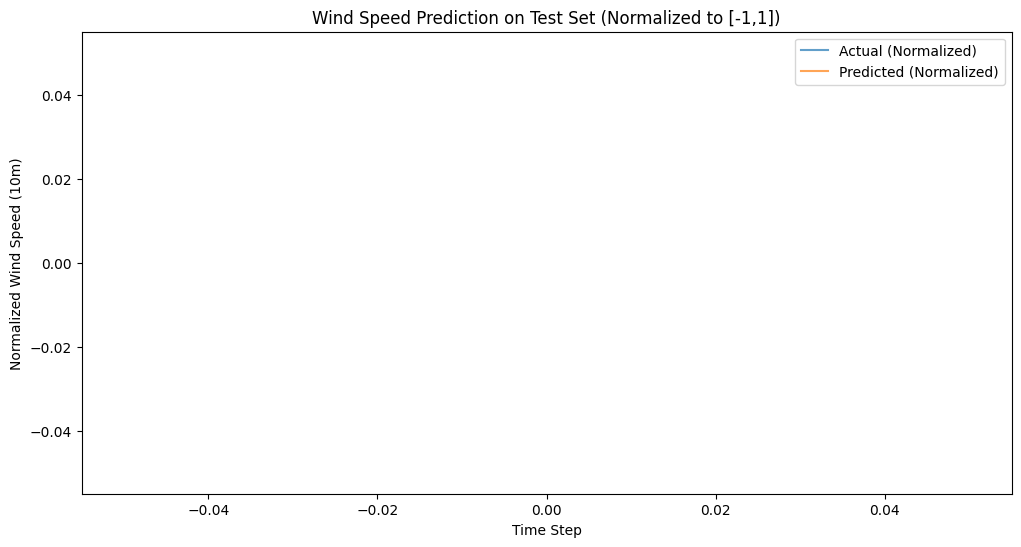

In [40]:

model.eval()
predictions = []
ground_truth = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        predictions.extend(output.cpu().numpy().flatten())
        ground_truth.extend(y_batch.cpu().numpy().flatten())

predictions = np.array(predictions)
ground_truth = np.array(ground_truth)

mse_norm = np.mean((predictions - ground_truth) ** 2)
rmse_norm = np.sqrt(mse_norm)
mae_norm = np.mean(np.abs(predictions - ground_truth))

print("Normalized Test MSE:", mse_norm)
print("Normalized Test RMSE:", rmse_norm)
print("Normalized Test MAE:", mae_norm)

plt.figure(figsize=(12,6))
plt.plot(ground_truth, label="Actual (Normalized)", alpha=0.7)
plt.plot(predictions, label="Predicted (Normalized)", alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Normalized Wind Speed (10m)")
plt.title("Wind Speed Prediction on Test Set (Normalized to [-1,1])")
plt.legend()
plt.show()

Raw data head:
                 time       temperature_2m  wind_speed_10m  wind_speed_100m  \
0 2015-01-01 00:00:00  temperature_2m (°C)            22.4             36.4   
1 2015-01-01 01:00:00  temperature_2m (°C)            22.2             36.4   
2 2015-01-01 02:00:00  temperature_2m (°C)            22.0             36.4   
3 2015-01-01 03:00:00  temperature_2m (°C)            21.5             35.7   
4 2015-01-01 04:00:00  temperature_2m (°C)            22.1             36.5   
5 2015-01-01 05:00:00  temperature_2m (°C)            21.2             35.6   
6 2015-01-01 06:00:00  temperature_2m (°C)            20.2             34.2   
7 2015-01-01 07:00:00  temperature_2m (°C)            21.4             35.9   
8 2015-01-01 08:00:00  temperature_2m (°C)            23.9             39.5   
9 2015-01-01 09:00:00  temperature_2m (°C)            23.2             37.8   

   wind_direction_10m  cloud_cover_mid  cloud_cover_high  cloud_cover_low  \
0               242.0             56.0

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/20 - Train Loss: 0.0260 | Test Loss: 0.0170
Epoch 2/20 - Train Loss: 0.0112 | Test Loss: 0.0140
Epoch 3/20 - Train Loss: 0.0118 | Test Loss: 0.0117
Epoch 4/20 - Train Loss: 0.0108 | Test Loss: 0.0121
Epoch 5/20 - Train Loss: 0.0101 | Test Loss: 0.0117
Epoch 6/20 - Train Loss: 0.0101 | Test Loss: 0.0109
Epoch 7/20 - Train Loss: 0.0095 | Test Loss: 0.0109
Epoch 8/20 - Train Loss: 0.0094 | Test Loss: 0.0109
Epoch 9/20 - Train Loss: 0.0098 | Test Loss: 0.0101
Epoch 10/20 - Train Loss: 0.0091 | Test Loss: 0.0100
Epoch 11/20 - Train Loss: 0.0090 | Test Loss: 0.0100
Epoch 12/20 - Train Loss: 0.0091 | Test Loss: 0.0098
Epoch 13/20 - Train Loss: 0.0088 | Test Loss: 0.0101
Epoch 14/20 - Train Loss: 0.0088 | Test Loss: 0.0098
Epoch 15/20 - Train Loss: 0.0088 | Test Loss: 0.0101
Epoch 16/20 - Train Loss: 0.0089 | Test Loss: 0.0094
Epoch 17/20 - Train Loss: 0.0085 | Test Loss: 0.0096
Epoch 18/20 - Train Loss: 0.0101 | Test Loss: 0.0097
Epoch 19/20 - Train Loss: 0.0087 | Test Loss: 0.0097
Ep

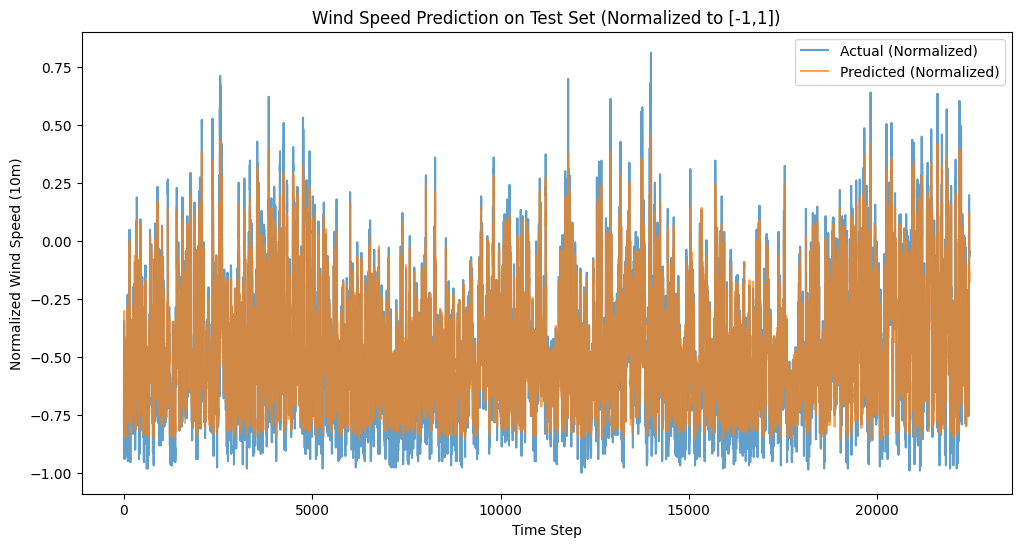

In [42]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 1. Load and inspect the data
df = pd.read_csv('pickeringWind.csv', parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)
print("Raw data head:")
print(df.head(10))

# Define the relevant columns.
# We now drop 'temperature_2m' because it is constant (all "2" after cleaning)
features = ['wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'pressure_msl']
target = 'wind_speed_10m'  # we predict wind_speed_10m

# Select only the needed columns.
data = df[features].copy()

# Clean the data:
# Remove any non-numeric characters (e.g. extra header text or units)
data = data.replace(r'[^\d.-]', '', regex=True)

# Convert columns to numeric values.
data[features] = data[features].apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN values.
data = data.dropna().reset_index(drop=True)
print("Cleaned data shape:", data.shape)
print("Cleaned data head:")
print(data.head())

# 2. Normalize the data.
# Normalize features using z-score normalization.
features_mean = data.mean()
features_std = data.std()
data_features = ((data - features_mean) / features_std).values

# Min–Max normalize the target to the range [-1, 1].
target_min = data[target].min()
target_max = data[target].max()
data_target = (2 * (data[target] - target_min) / (target_max - target_min) - 1).values

# 3. Create sequences using a sliding window.
sequence_length = 24  # for example, use the past 24 time steps to predict the next value

def create_sequences(X, y, seq_length):
    seq_X, seq_y = [], []
    for i in range(len(X) - seq_length):
        seq_X.append(X[i:i+seq_length])
        seq_y.append(y[i+seq_length])
    return np.array(seq_X), np.array(seq_y)

X_seq, y_seq = create_sequences(data_features, data_target, sequence_length)
print("X_seq shape:", X_seq.shape, "y_seq shape:", y_seq.shape)

# 4. Split the data (first 75% for training, last 25% for testing)
train_size = int(len(X_seq) * 0.75)
X_train, y_train = X_seq[:train_size], y_seq[:train_size]
X_test, y_test = X_seq[train_size:], y_seq[train_size:]

# 5. Define a PyTorch Dataset.
class WindDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        # Ensure target has shape (n, 1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = WindDataset(X_train, y_train)
test_dataset = WindDataset(X_test, y_test)

batch_size = 32
# Do not shuffle for time series
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 6. Define the Transformer model with positional encoding.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        positions = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(positions * div_term)
        pe[:, 1::2] = torch.cos(positions * div_term)
        pe = pe.unsqueeze(1)  # Shape: (max_len, 1, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (sequence_length, batch_size, d_model)
        return x + self.pe[:x.size(0)]

class WindTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=8, num_encoder_layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, src):
        # src: (batch_size, sequence_length, num_features)
        # Transformer expects (sequence_length, batch_size, num_features)
        src = src.transpose(0, 1)
        x = self.input_proj(src)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        # Use the output from the last time step
        return self.decoder(x[-1])

# 7. Train the model.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = WindTransformer(num_features=len(features)).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_dataset)

    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            test_loss += loss.item() * X_batch.size(0)
    test_loss /= len(test_dataset)

    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

print("Training completed.")

# 8. Evaluate the model and plot predictions (on the normalized scale).
model.eval()
predictions = []
ground_truth = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)
        predictions.extend(output.cpu().numpy().flatten())
        ground_truth.extend(y_batch.cpu().numpy().flatten())

predictions = np.array(predictions)
ground_truth = np.array(ground_truth)

mse_norm = np.mean((predictions - ground_truth) ** 2)
rmse_norm = np.sqrt(mse_norm)
mae_norm = np.mean(np.abs(predictions - ground_truth))

print("Normalized Test MSE:", mse_norm)
print("Normalized Test RMSE:", rmse_norm)
print("Normalized Test MAE:", mae_norm)

plt.figure(figsize=(12,6))
plt.plot(ground_truth, label="Actual (Normalized)", alpha=0.7)
plt.plot(predictions, label="Predicted (Normalized)", alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Normalized Wind Speed (10m)")
plt.title("Wind Speed Prediction on Test Set (Normalized to [-1,1])")
plt.legend()
plt.show()
